In [15]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [16]:
LEARNING_RATE = 0.001
TRAIN_PATH = '../../flower_dataset/train'
VAL_PATH = '../../flower_dataset/valid'
TEST_PATH = '../../flower_dataset/test'
BATCH_SIZE = 64
EPOCH = 50

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=data_transform)
val_dataset = datasets.ImageFolder(root=VAL_PATH, transform=data_transform)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=data_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [18]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block_1 = nn.Sequential(nn.Conv2d(3, 32, 3, stride=1, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2))
        self.block_2 = nn.Sequential(nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.hidden = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 512), nn.ReLU() , nn.Dropout(0.2), nn.Linear(512, 102))
        

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.hidden(x)
        return x

In [19]:
model = CNN()

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loss_list, val_loss_list, train_acc_list, val_acc_list = [], [], [], []

for epoch in range(EPOCH):
    train_loss_sum = 0
    train_correct = 0
    train_total = 0

    model.train()
        
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)    

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        train_loss_sum += loss.item()

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / len(train_loader)
    train_acc = train_correct / train_total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()

    val_loss_sum = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item()

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)


    val_loss = val_loss_sum / len(val_loader)
    val_acc = val_correct / val_total

    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch}:Train Loss: {train_loss} | Val Loss: {val_loss}")
    

Epoch 0:Train Loss: 4.14925359579233 | Val Loss: 3.6867638006806374
Epoch 1:Train Loss: 3.473663176023043 | Val Loss: 3.3036399856209755
Epoch 2:Train Loss: 3.1935785330258883 | Val Loss: 3.064694955945015
Epoch 3:Train Loss: 3.0177395050342266 | Val Loss: 2.9447583854198456
Epoch 4:Train Loss: 2.868198266396156 | Val Loss: 2.8633628115057945
Epoch 5:Train Loss: 2.768748400761531 | Val Loss: 2.8187249042093754
Epoch 6:Train Loss: 2.691908931732178 | Val Loss: 2.7714460380375385
Epoch 7:Train Loss: 2.593959595606877 | Val Loss: 2.6404314897954464
Epoch 8:Train Loss: 2.5418460515829233 | Val Loss: 2.605844210833311
Epoch 9:Train Loss: 2.485738838635958 | Val Loss: 2.5695527140051126
Epoch 10:Train Loss: 2.4590587542607234 | Val Loss: 2.534822590649128
Epoch 11:Train Loss: 2.4025704860687256 | Val Loss: 2.5440472960472107
Epoch 12:Train Loss: 2.3732914777902456 | Val Loss: 2.4970708787441254
Epoch 13:Train Loss: 2.3232135497606716 | Val Loss: 2.5072448570281267
Epoch 14:Train Loss: 2.2838

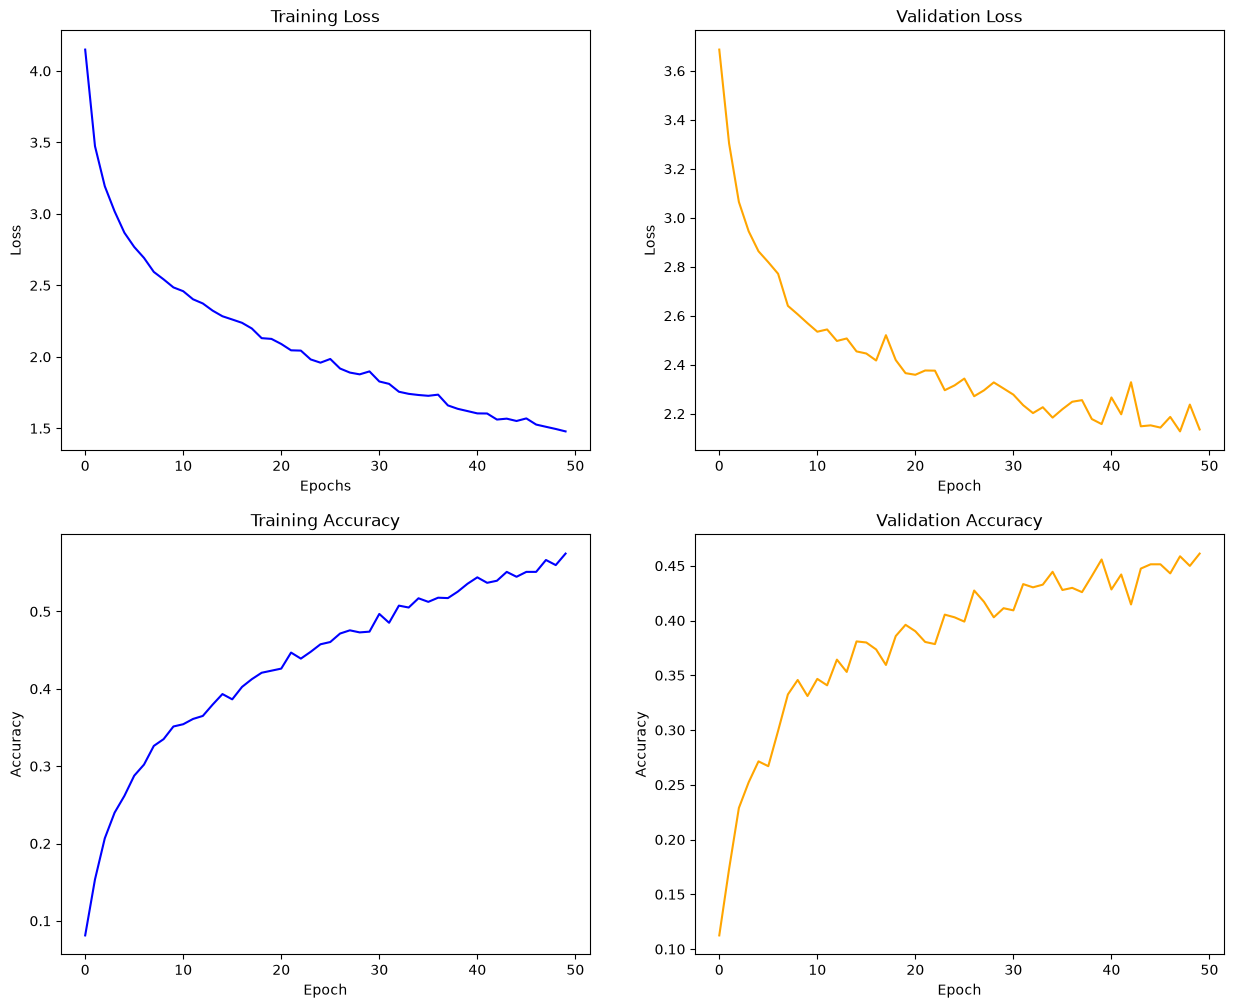

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 12))

ax1[0].plot(train_loss_list, color='blue')
ax1[0].set_title('Training Loss')
ax1[0].set_xlabel('Epochs')
ax1[0].set_ylabel('Loss')

ax1[1].plot(val_loss_list, color='orange')
ax1[1].set_title('Validation Loss')
ax1[1].set_xlabel('Epoch')
ax1[1].set_ylabel('Loss')

ax2[0].plot(train_acc_list, color='blue')
ax2[0].set_title('Training Accuracy')
ax2[0].set_xlabel('Epoch')
ax2[0].set_ylabel('Accuracy')

ax2[1].plot(val_acc_list, color='orange')
ax2[1].set_title('Validation Accuracy')
ax2[1].set_xlabel('Epoch')
ax2[1].set_ylabel('Accuracy')


plt.show()

In [21]:
model.eval()

correct = 0
samples = 0

preds = []
true = []


with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        samples += labels.size(0)

        preds.extend(predicted.tolist())
        true.extend(labels.tolist())

accuracy = correct/samples
print(accuracy)

0.44319294809010773
